# 02 Core EDA
Runs the core descriptive analysis and plots used for interpretation/reporting.

Prerequisite: run 01_data_prep.ipynb first.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

data_dir = Path('../data')
eda_path = data_dir / 'eda_df.csv'
retro_path = data_dir / 'model_B_retrospective_dataset.csv'

eda_df = pd.read_csv(eda_path)
model_B_df = pd.read_csv(retro_path) if retro_path.exists() else pd.DataFrame()

print('eda_df shape:', eda_df.shape)
print('model_B_df shape:', model_B_df.shape)

eda_df shape: (91812, 36)
model_B_df shape: (91812, 33)


In [2]:
summary_cols = [c for c in ['WAITTIME', 'AGE', 'PAINSCALE', 'BPSYS', 'BPDIAS', 'TEMPF', 'PULSE', 'RESPR', 'POPCT'] if c in eda_df.columns]
display(eda_df[summary_cols].describe().T)

missingness = eda_df.isna().mean().sort_values(ascending=False).reset_index()
missingness.columns = ['feature', 'missing_rate']
display(missingness.head(20))

,count,mean,std,min,25%,50%,75%,max
WAITTIME,91812.0,34.080959,50.563706,0.0,6.0,16.0,39.0,477.0
AGE,91812.0,38.782567,24.431619,0.0,20.0,36.0,57.0,94.0
PAINSCALE,91812.0,0.454832,6.742776,-9.0,-8.0,0.0,7.0,10.0
BPSYS,91812.0,120.337973,48.044174,-9.0,112.0,129.0,145.0,289.0
BPDIAS,91812.0,70.423060,33.321463,-9.0,65.0,76.0,87.0,998.0
TEMPF,91812.0,937.947098,206.793781,-9.0,977.0,981.0,986.0,1090.0
PULSE,91812.0,87.308576,45.123687,-9.0,74.0,87.0,101.0,998.0
RESPR,91812.0,18.500229,8.219690,-9.0,16.0,18.0,20.0,150.0
POPCT,91812.0,91.474709,24.829513,-9.0,96.0,98.0,99.0,100.0


,feature,missing_rate
0,EDWT,0.805025
1,BOARDED,0.332963
2,LOV,0.332963
3,WAITTIME,0.000000
4,BEDCZAR,0.000000
5,PULSE,0.000000
6,RESPR,0.000000
7,POPCT,0.000000
8,BEDREG,0.000000
9,IMBED,0.000000


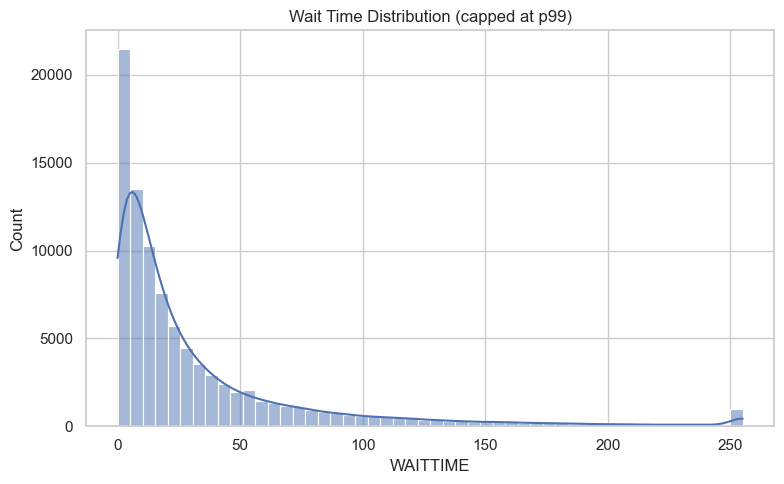

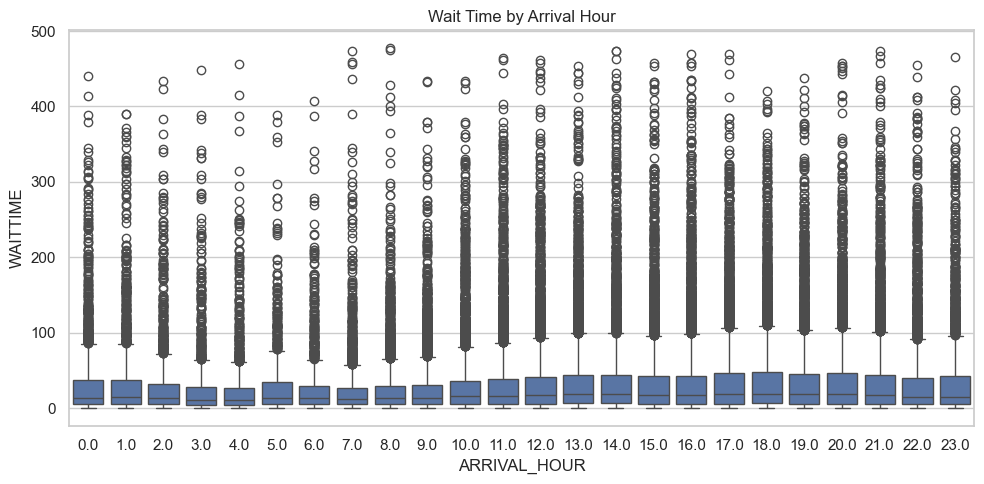

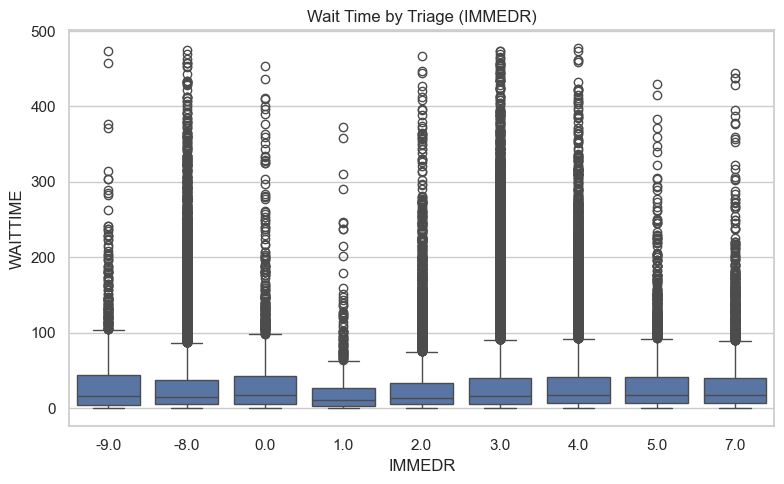

In [3]:
if 'WAITTIME' in eda_df.columns:
    plot_df = eda_df.copy()
    cap = plot_df['WAITTIME'].quantile(0.99)
    plot_df['WAITTIME_CAPPED'] = plot_df['WAITTIME'].clip(upper=cap)

    plt.figure(figsize=(8, 5))
    sns.histplot(plot_df['WAITTIME_CAPPED'], bins=50, kde=True)
    plt.title('Wait Time Distribution (capped at p99)')
    plt.xlabel('WAITTIME')
    plt.tight_layout()
    plt.show()

if set(['ARRIVAL_HOUR', 'WAITTIME']).issubset(eda_df.columns):
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=eda_df, x='ARRIVAL_HOUR', y='WAITTIME')
    plt.title('Wait Time by Arrival Hour')
    plt.tight_layout()
    plt.show()

if set(['IMMEDR', 'WAITTIME']).issubset(eda_df.columns):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=eda_df, x='IMMEDR', y='WAITTIME')
    plt.title('Wait Time by Triage (IMMEDR)')
    plt.tight_layout()
    plt.show()

,VDAYR,count,mean,median
0,1.0,12163,30.689386,15.0
1,2.0,14903,37.518151,17.0
2,3.0,13669,35.753530,17.0
3,4.0,13288,35.420680,16.0
4,5.0,12858,33.818868,16.0
5,6.0,12687,33.860487,16.0
6,7.0,12244,30.448955,14.0


,ARRIVAL_HOUR,count,mean,median
0,0.0,2108,32.618121,14.0
1,1.0,1959,34.432874,15.0
2,2.0,1579,30.638379,13.0
3,3.0,1377,27.653595,11.0
4,4.0,1190,27.876471,11.0
5,5.0,1268,28.753155,14.0
6,6.0,1610,25.812422,13.0
7,7.0,2367,24.512041,12.0
8,8.0,3651,24.908518,13.0
9,9.0,4776,26.651173,14.0


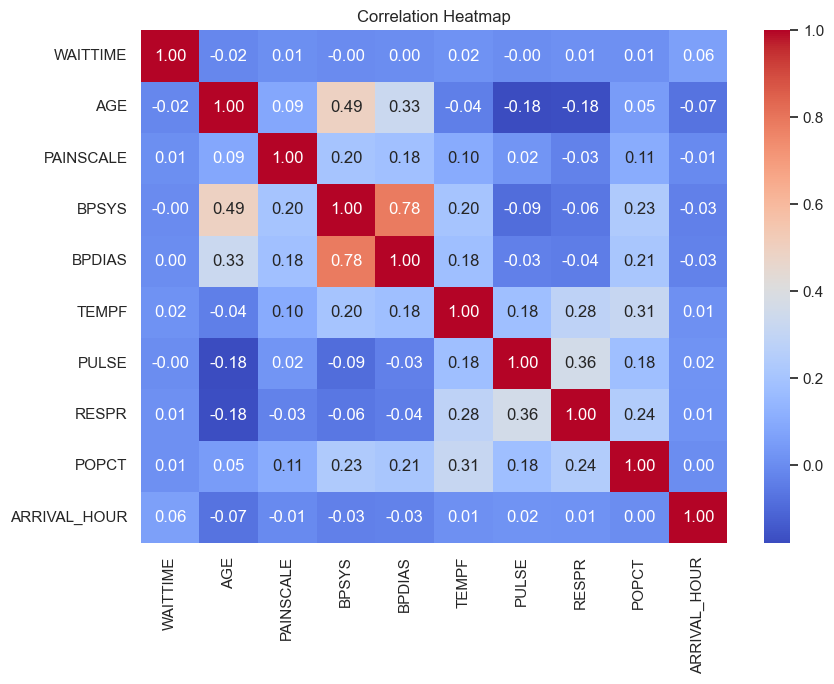

In [4]:
if set(['WAITTIME', 'VDAYR']).issubset(eda_df.columns):
    day_summary = eda_df.groupby('VDAYR', dropna=False)['WAITTIME'].agg(['count', 'mean', 'median']).reset_index()
    display(day_summary)

if set(['WAITTIME', 'ARRIVAL_HOUR']).issubset(eda_df.columns):
    hour_summary = eda_df.groupby('ARRIVAL_HOUR', dropna=False)['WAITTIME'].agg(['count', 'mean', 'median']).reset_index()
    display(hour_summary)

corr_cols = [c for c in ['WAITTIME', 'AGE', 'PAINSCALE', 'BPSYS', 'BPDIAS', 'TEMPF', 'PULSE', 'RESPR', 'POPCT', 'ARRIVAL_HOUR'] if c in eda_df.columns]
if len(corr_cols) >= 2:
    corr_df = eda_df[corr_cols].apply(pd.to_numeric, errors='coerce')
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()

In [5]:
if not model_B_df.empty and set(['WAITTIME', 'FASTTRAK', 'OBSCLIN', 'BOARD']).intersection(model_B_df.columns):
    for c in ['FASTTRAK', 'OBSCLIN', 'BOARD', 'ADMIT']:
        if c in model_B_df.columns and 'WAITTIME' in model_B_df.columns:
            print(f'WAITTIME by {c}')
            display(model_B_df.groupby(c, dropna=False)['WAITTIME'].agg(['count', 'mean', 'median']).reset_index())

out_path = Path('../data/eda_gap_report.csv')
missingness.to_csv(out_path, index=False)
print('Saved:', out_path)

WAITTIME by FASTTRAK


,FASTTRAK,count,mean,median
0,-9.0,165,52.084848,30.0
1,-8.0,6132,41.204175,21.0
2,1.0,52245,34.678419,16.0
3,2.0,33270,31.740577,15.0


WAITTIME by OBSCLIN


,OBSCLIN,count,mean,median
0,-9.0,134,60.888060,36.0
1,-8.0,5417,34.721617,18.0
2,1.0,38897,35.433452,16.0
3,2.0,47364,32.821130,15.0


WAITTIME by BOARD


,BOARD,count,mean,median
0,-9.0,134,60.888060,36.0
1,-8.0,5526,38.822837,20.0
2,1.0,69553,35.278838,16.0
3,2.0,16599,27.266582,15.0


WAITTIME by ADMIT


,ADMIT,count,mean,median
0,-9.0,69,34.362319,12.0
1,-8.0,1195,33.347280,14.0
2,-7.0,81755,34.347624,16.0
3,1.0,1506,26.094954,10.0
4,2.0,404,34.282178,14.0
5,3.0,687,30.547307,13.0
6,4.0,467,35.751606,20.0
7,5.0,192,27.208333,10.0
8,6.0,5537,32.991692,14.0


Saved: ../data/eda_gap_report.csv
